<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/0508_%EC%84%B8%EC%85%98_RNN_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 데이터 가져오기
import pandas as pd
data= pd.read_csv('/content/drive/MyDrive/ESSA/netflix_train.csv')
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


/tmp/ipykernel_923/1265059895.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_used['Close'] = data['Close']


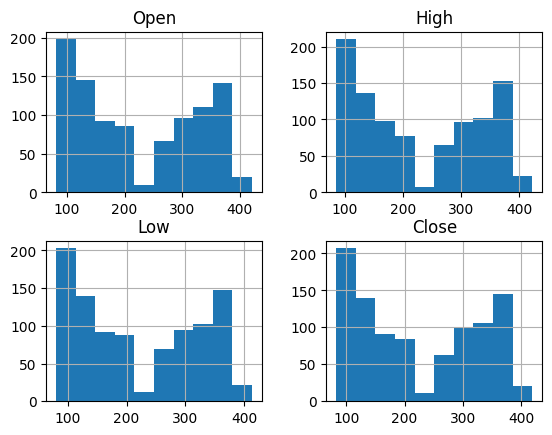

In [4]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt

# 개장가, 최고가, 최저가 추가
data_used = data[['Open', 'High', 'Low']]
# 종가 추가
data_used['Close'] = data['Close']
hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [5]:
import numpy as np
from torch.utils.data.dataset import Dataset

class Netflix(Dataset):  # 클래스 선언
    def __init__(self):
       # 데이터 읽기
        data = pd.read_csv('/content/drive/MyDrive/ESSA/netflix_train.csv')

       # 입력 데이터 정규화
          # 종가를 제외한 데이터

        self.data = data[['Open', 'High', 'Low']].values

          # 0과 1 사이로 정규화
        self.data = (self.data -np.min(self.data, axis=0))/ (np.max(self.data, axis=0)-np.min(self.data, axis=0))

       # 종가 데이터 정규화
        self.label = data['Close'].values
        self.label = (self.label - np.min(self.label))/(np.max(self.label)-np.min(self.label))

    def __len__(self):
        return len(self.data) - 30 # 사용 가능한 배치 개수

    def __getitem__(self, i):
        # 입력 데이터 30일치 읽기
        data = self.data[i:i+30]

        # 종가 데이터 30일치 읽기
        label = self.label[i:i+30]

        return data, label

## 3. RNN 모델 정의

In [6]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

       # RNN층의 정의
        self.rnn= nn.RNN(
           input_size=3,
           hidden_size=8,
           num_layers=5,
           batch_first=True
        )


       # 주가를 예측하는 MLP층 정의
        self.fc1= nn.Linear(in_features=8, out_features=64)
        self.fc2= nn.Linear(in_features=64, out_features=1)


       # 활성화 함수 정의
        self.relu= nn.ReLU()

# RNN 모델의 순전파 정의
    def forward(self, x, h0):
         # RNN층의 출력
        x, hn= self.rnn(x, h0)

       # MLP층의 입력으로 사용되게 모양 변경
        x= x.reshape(-1, 8)

       # MLP층을 이용해 종가 예측
        x= self.fc1(x)
        x= self.relu(x)
        x= self.fc2(x)

       # 예측한 종가를 1차원 벡터로 표현
        x= x.flatten()

        return x

## 4. 모델 학습하기

In [7]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
model= RNN().to(device)

# 데이터셋의 정의
dataset=Netflix()

In [8]:
# 데이터로더 정의
  # 배치 크기를 32로 설정
loader= DataLoader(dataset, batch_size=32, shuffle=True)

In [9]:
# 최적화 정의
# 학습률은 0.0001로 설정
lr= 0.0001
 # 사용할 최적화 설정
optim= Adam(model.parameters(), lr=lr)

In [13]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
    iterator= tqdm.tqdm(loader)

    for data, label in iterator:
        optim.zero_grad()

        data=data.to(device).float()
        label= label.to(device).float()
        # 초기 은닉 상태
        h0= torch.zeros(5, data.shape[0],8).to(device)


       # 모델의 예측값
        pred= model(data, h0)


       # 손실의 계산
        loss= nn.MSELoss()(pred, label.flatten())

        # 손실 역전파
        loss.backward()


         # 최적화 진행
        optim.step()

        iterator.set_description(f"epoch{epoch} loss:{loss.item()}")

  # 모델 저장
torch.save(model.state_dict(), 'rnn.pth')

epoch199 loss:0.00021205825032666326: 100%|██████████| 30/30 [00:00<00:00, 47.85it/s]


## 5. 모델 성능 평가하기

In [29]:
import matplotlib.pyplot as plt

  # 예측값을 위한 데이터로더
loader= DataLoader(dataset, batch_size=32, shuffle=False)
  # 예측값들을 저장하는 리스트
preds= []
actual=[]
total_loss = 0

with torch.no_grad():
   # 모델의 가중치 불러오기
    model.load_state_dict(torch.load('rnn.pth', map_location=device))
    model.to(device)
    model.eval()


    for data, label in loader:
        data=data.to(device).float()
        label= label.to(device).float()
         # 초기 은닉 상태 정의
        h0= torch.zeros(5, data.shape[0],8).to(device)
       # 모델의 예측값 출력
        pred= model(data, h0)
        pred= pred.reshape(data.shape[0],30)

         # 예측값을 리스트에 추가
        preds.extend(pred[:,-1].cpu().numpy())
        actual.extend(label[:,-1].cpu().numpy())


       # 손실 계산
        loss= nn.MSELoss()(pred, label)
        total_loss += loss

       # 손실의 평균치 계산
total_loss= total_loss/ len(loader)

print(total_loss.item())

0.0001829117682063952


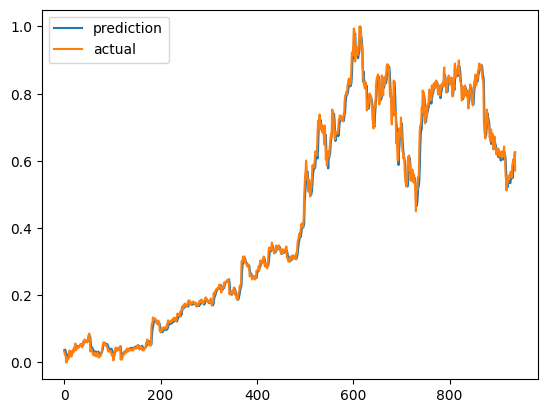

In [30]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.label[30:], label="actual")
plt.legend()
plt.show()